# SBI on CSTR (clean data)

## Setup 

Initialising conditions and the simulator

In [62]:
from tools import run_sbi, pre_simulator
import numpy as np

# visualization
import matplotlib as mpl
import matplotlib.pyplot as plt

inlet_conditions =  [0.97, 351.5, 351.6, 150]
true_params = [7E5, 7.2E10]

# Use simulator to get observation
observation = np.round(pre_simulator(inlet_conditions, true_params),2)
print(observation)

[1.1000e-01 4.2870e+02 4.1499e+02]


## Recovering true parameters as function of num_simulations

Idea is to recover the true parameters from the observation. 

* Can we get values that are close to the true values?
* How is this affected by the change in the number of simulations?

In [1]:
from functools import partial
from sbi import utils as utils
from sbi.inference.base import infer
from sbi import analysis

simulator = partial(pre_simulator, inlet_conditions)
prior = utils.BoxUniform(low=[6E5,1E10], 
                         high=[10E5,10E10])

posterior = infer(simulator, prior, method='SNPE', num_simulations=100, num_workers=5)

NameError: name 'pre_simulator' is not defined

Drawing 100000 posterior samples:   0%|          | 0/100000 [00:00<?, ?it/s]

UA is  tensor(785318.5625) +- tensor(291831.4062)
k_0 is  tensor(7.9242e+10) +- tensor(2.5145e+10)


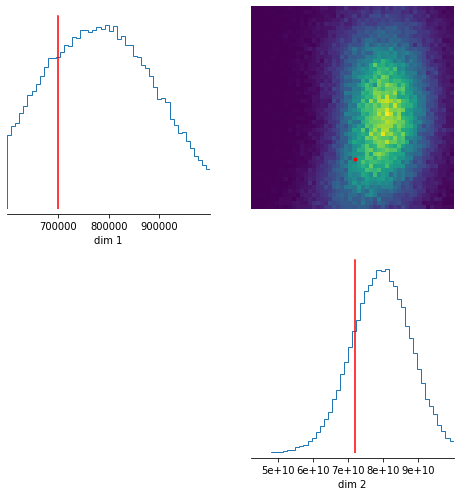

In [54]:
samples = posterior.sample((100000,), x=observation)

_ = analysis.pairplot(samples,
                      points=np.array(true_params),
                      figsize=(8,8),
                      #limits=[[6E5,10E5]],
                      points_colors='r',
                      points_offdiag={'markersize': 6},
                     )

print('UA is ',samples[:,0].mean(),'+-',3*samples[:,0].std())
print('k_0 is ',samples[:,1].mean(),'+-',3*samples[:,1].std())

In [55]:
np.round(pre_simulator(inlet_conditions, [samples[:,0].mean(),samples[:,1].mean()]),2)

array([1.0000e-01, 4.2863e+02, 4.1622e+02])

In [72]:

posterior = infer(simulator, prior, method='SNPE', num_simulations=1000, num_workers=5)

/home/keepfloyding/.env/lib64/python3.9/site-packages/scipy/integrate/_ivp/base.py:20: FutureWarning: The input object of type 'Tensor' is an array-like implementing one of the corresponding protocols (`__array__`, `__array_interface__` or `__array_struct__`); but not a sequence (or 0-D). In the future, this object will be coerced as if it was first converted using `np.array(obj)`. To retain the old behaviour, you have to either modify the type 'Tensor', or assign to an empty array created with `np.empty(correct_shape, dtype=object)`.
  return np.asarray(fun(t, y), dtype=dtype)


Running 1000 simulations in 1000 batches.:   0%|          | 0/1000 [00:00<?, ?it/s]

/home/keepfloyding/Projects/inso-po-RD/cstr-model-optimisation/tools.py:75: RuntimeWarning: Solution not converged. [1.29461223 0.00892595 0.1334646 ]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
/home/keepfloyding/Projects/inso-po-RD/cstr-model-optimisation/tools.py:75: RuntimeWarning: Solution not converged. [2.52144587 0.01550944 0.04302346]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
/home/keepfloyding/Projects/inso-po-RD/cstr-model-optimisation/tools.py:75: RuntimeWarning: Solution not converged. [1.11345646 0.04466223 0.09674714]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
/home/keepfloyding/Projects/inso-po-RD/cstr-model-optimisation/tools.py:75: RuntimeWarning: Solution not converged. [1.88463062e+00 9.22484778e-02 1.14032097e-03]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
/home/keepfloyding/Projects/inso-po-RD/cstr-model-optimisation/tools.py:75: RuntimeWarning: Solu

 Neural network successfully converged after 118 epochs.

Drawing 100000 posterior samples:   0%|          | 0/100000 [00:00<?, ?it/s]

UA is  tensor(794973.1250) +- tensor(289254.5000)
k_0 is  tensor(7.4749e+10) +- tensor(1.6499e+10)


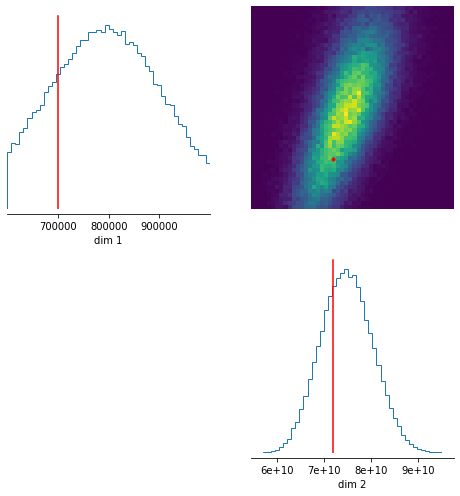

In [73]:
samples = posterior.sample((100000,), x=observation)

_ = analysis.pairplot(samples,
                      points=np.array(true_params),
                      figsize=(8,8),
                      #limits=[[6E5,10E5]],
                      points_colors='r',
                      points_offdiag={'markersize': 6},
                     )

print('UA is ',samples[:,0].mean(),'+-',3*samples[:,0].std())
print('k_0 is ',samples[:,1].mean(),'+-',3*samples[:,1].std())

(array([ 918., 1064., 1052., 1240., 1309., 1463., 1567., 1601., 1672.,
        1895., 1979., 2047., 2183., 2297., 2336., 2424., 2514., 2623.,
        2718., 2720., 2845., 2853., 2882., 2850., 2961., 2902., 2850.,
        2809., 2866., 2654., 2685., 2639., 2509., 2465., 2311., 2232.,
        2016., 2002., 1819., 1692., 1685., 1497., 1372., 1339., 1169.,
        1016.,  974.,  872.,  867.,  745.]),
 array([600004.5625, 608004.365 , 616004.1675, 624003.97  , 632003.7725,
        640003.575 , 648003.3775, 656003.18  , 664002.9825, 672002.785 ,
        680002.5875, 688002.39  , 696002.1925, 704001.995 , 712001.7975,
        720001.6   , 728001.4025, 736001.205 , 744001.0075, 752000.81  ,
        760000.6125, 768000.415 , 776000.2175, 784000.02  , 791999.8225,
        799999.625 , 807999.4275, 815999.23  , 823999.0325, 831998.835 ,
        839998.6375, 847998.44  , 855998.2425, 863998.045 , 871997.8475,
        879997.65  , 887997.4525, 895997.255 , 903997.0575, 911996.86  ,
        919996.6

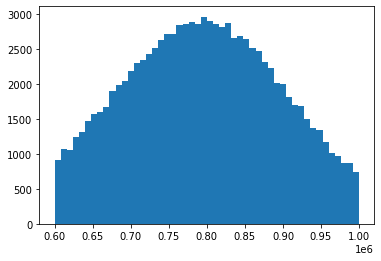

In [83]:
plt.hist(x,bins=50)

In [107]:
idx = np.where((np.array(x)>0.7999e6)&(np.array(x)<0.8001e6))



In [108]:
y = np.array([sample[1] for sample in samples])
ans = y[idx]

(array([1., 3., 0., 3., 1., 1., 1., 1., 2., 1., 3., 1., 1., 0., 2., 2., 1.,
        1., 0., 1., 2., 1., 0., 2., 3., 4., 0., 4., 0., 2., 1., 0., 1., 4.,
        1., 2., 2., 1., 2., 1., 4., 0., 3., 0., 4., 1., 1., 0., 2., 3.]),
 array([799901.75   , 799905.69625, 799909.6425 , 799913.58875,
        799917.535  , 799921.48125, 799925.4275 , 799929.37375,
        799933.32   , 799937.26625, 799941.2125 , 799945.15875,
        799949.105  , 799953.05125, 799956.9975 , 799960.94375,
        799964.89   , 799968.83625, 799972.7825 , 799976.72875,
        799980.675  , 799984.62125, 799988.5675 , 799992.51375,
        799996.46   , 800000.40625, 800004.3525 , 800008.29875,
        800012.245  , 800016.19125, 800020.1375 , 800024.08375,
        800028.03   , 800031.97625, 800035.9225 , 800039.86875,
        800043.815  , 800047.76125, 800051.7075 , 800055.65375,
        800059.6    , 800063.54625, 800067.4925 , 800071.43875,
        800075.385  , 800079.33125, 800083.2775 , 800087.22375,
      

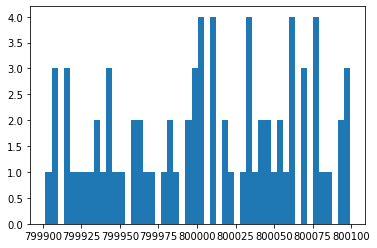

In [109]:
plt.hist(np.array(x)[idx],bins=50)

In [111]:
np.median(ans)

76356100000.0

In [119]:
max(ans)

85398240000.0

In [120]:
observation = np.round(pre_simulator(inlet_conditions, [0.8e6,85398240000.0]),2)
observation

array([9.0000e-02, 4.2938e+02, 4.1671e+02])

In [79]:
np.random.rand(10, 12)

array([[0.73778897, 0.03717205, 0.37487696, 0.15853474, 0.82094739,
        0.05499593, 0.62767257, 0.88143149, 0.52001998, 0.9681399 ,
        0.80186203, 0.28076245],
       [0.73788798, 0.60950768, 0.02258419, 0.29023627, 0.3140723 ,
        0.95972534, 0.02454109, 0.5780801 , 0.16675841, 0.49219526,
        0.94425948, 0.41423806],
       [0.36214381, 0.17254677, 0.2792521 , 0.61954589, 0.55766817,
        0.52278336, 0.15270307, 0.6771419 , 0.65319105, 0.41694167,
        0.48098348, 0.80990544],
       [0.03395411, 0.12066335, 0.45063057, 0.59661374, 0.63080868,
        0.85342878, 0.11246145, 0.25508366, 0.10101549, 0.53375802,
        0.22513533, 0.59330226],
       [0.61049408, 0.22372101, 0.62479463, 0.35680894, 0.24463524,
        0.17965612, 0.77062696, 0.85845038, 0.28649806, 0.70053128,
        0.15430006, 0.67427129],
       [0.05747883, 0.62517771, 0.28077119, 0.41829998, 0.93899466,
        0.96637568, 0.52287679, 0.39218075, 0.55832269, 0.17647769,
        0.81770738,

In [58]:
posterior = infer(simulator, prior, method='SNPE', num_simulations=10000, num_workers=5)

/home/keepfloyding/.env/lib64/python3.9/site-packages/scipy/integrate/_ivp/base.py:20: FutureWarning: The input object of type 'Tensor' is an array-like implementing one of the corresponding protocols (`__array__`, `__array_interface__` or `__array_struct__`); but not a sequence (or 0-D). In the future, this object will be coerced as if it was first converted using `np.array(obj)`. To retain the old behaviour, you have to either modify the type 'Tensor', or assign to an empty array created with `np.empty(correct_shape, dtype=object)`.
  return np.asarray(fun(t, y), dtype=dtype)


Running 10000 simulations in 10000 batches.:   0%|          | 0/10000 [00:00<?, ?it/s]

/home/keepfloyding/Projects/inso-po-RD/cstr-model-optimisation/tools.py:75: RuntimeWarning: Solution not converged. [5.94313451 0.14159673 0.31126764]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
/home/keepfloyding/Projects/inso-po-RD/cstr-model-optimisation/tools.py:75: RuntimeWarning: Solution not converged. [8.43280759 0.31658586 0.17456539]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
/home/keepfloyding/Projects/inso-po-RD/cstr-model-optimisation/tools.py:75: RuntimeWarning: Solution not converged. [1.33580297 0.05153197 0.02352214]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
/home/keepfloyding/Projects/inso-po-RD/cstr-model-optimisation/tools.py:75: RuntimeWarning: Solution not converged. [1.2892967  0.04670725 0.03635085]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
/home/keepfloyding/Projects/inso-po-RD/cstr-model-optimisation/tools.py:75: RuntimeWarning: Solution not con

/home/keepfloyding/Projects/inso-po-RD/cstr-model-optimisation/tools.py:75: RuntimeWarning: Solution not converged. [1.47174307 0.06068415 0.07028429]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
/home/keepfloyding/Projects/inso-po-RD/cstr-model-optimisation/tools.py:75: RuntimeWarning: Solution not converged. [1.23669153 0.04616963 0.09114199]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
/home/keepfloyding/Projects/inso-po-RD/cstr-model-optimisation/tools.py:75: RuntimeWarning: Solution not converged. [1.33764969 0.08024218 0.02001439]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
/home/keepfloyding/Projects/inso-po-RD/cstr-model-optimisation/tools.py:75: RuntimeWarning: Solution not converged. [1.29929319 0.05278325 0.09241609]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
/home/keepfloyding/Projects/inso-po-RD/cstr-model-optimisation/tools.py:75: RuntimeWarning: Solution not con

/home/keepfloyding/Projects/inso-po-RD/cstr-model-optimisation/tools.py:75: RuntimeWarning: Solution not converged. [7.53798034 0.26702011 0.10928182]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
/home/keepfloyding/Projects/inso-po-RD/cstr-model-optimisation/tools.py:75: RuntimeWarning: Solution not converged. [2.85857809 0.01570573 0.03481902]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
/home/keepfloyding/Projects/inso-po-RD/cstr-model-optimisation/tools.py:75: RuntimeWarning: Solution not converged. [8.54301661 0.32332974 0.3085183 ]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
/home/keepfloyding/Projects/inso-po-RD/cstr-model-optimisation/tools.py:75: RuntimeWarning: Solution not converged. [1.49595643 0.06689287 0.09773336]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
/home/keepfloyding/Projects/inso-po-RD/cstr-model-optimisation/tools.py:75: RuntimeWarning: Solution not con

/home/keepfloyding/Projects/inso-po-RD/cstr-model-optimisation/tools.py:75: RuntimeWarning: Solution not converged. [1.0323306  0.05939221 0.06626477]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
/home/keepfloyding/Projects/inso-po-RD/cstr-model-optimisation/tools.py:75: RuntimeWarning: Solution not converged. [1.46319711 0.10166027 0.06066677]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
/home/keepfloyding/Projects/inso-po-RD/cstr-model-optimisation/tools.py:75: RuntimeWarning: Solution not converged. [1.67639002 0.01724332 0.02657261]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
/home/keepfloyding/Projects/inso-po-RD/cstr-model-optimisation/tools.py:75: RuntimeWarning: Solution not converged. [1.40563883 0.0996259  0.06952089]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
/home/keepfloyding/Projects/inso-po-RD/cstr-model-optimisation/tools.py:75: RuntimeWarning: Solution not con

/home/keepfloyding/Projects/inso-po-RD/cstr-model-optimisation/tools.py:75: RuntimeWarning: Solution not converged. [1.54126253 0.06977231 0.12178801]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
/home/keepfloyding/Projects/inso-po-RD/cstr-model-optimisation/tools.py:75: RuntimeWarning: Solution not converged. [3.23575891 0.32214788 0.12248996]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
/home/keepfloyding/Projects/inso-po-RD/cstr-model-optimisation/tools.py:75: RuntimeWarning: Solution not converged. [1.10131125 0.09141938 0.05878182]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
/home/keepfloyding/Projects/inso-po-RD/cstr-model-optimisation/tools.py:75: RuntimeWarning: Solution not converged. [1.28183635 0.03957313 0.07273946]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
/home/keepfloyding/Projects/inso-po-RD/cstr-model-optimisation/tools.py:75: RuntimeWarning: Solution not con

/home/keepfloyding/Projects/inso-po-RD/cstr-model-optimisation/tools.py:75: RuntimeWarning: Solution not converged. [3.41703615e+00 8.64780914e-02 1.34358980e-03]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
/home/keepfloyding/Projects/inso-po-RD/cstr-model-optimisation/tools.py:75: RuntimeWarning: Solution not converged. [1.49263555 0.06302325 0.02214042]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
/home/keepfloyding/Projects/inso-po-RD/cstr-model-optimisation/tools.py:75: RuntimeWarning: Solution not converged. [1.16675965 0.08828941 0.01312505]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
/home/keepfloyding/Projects/inso-po-RD/cstr-model-optimisation/tools.py:75: RuntimeWarning: Solution not converged. [1.30240727 0.07304308 0.04325581]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
/home/keepfloyding/Projects/inso-po-RD/cstr-model-optimisation/tools.py:75: RuntimeWarning: Solu

 Neural network successfully converged after 153 epochs.

Drawing 100000 posterior samples:   0%|          | 0/100000 [00:00<?, ?it/s]

UA is  tensor(781627.9375) +- tensor(310576.0625)
k_0 is  tensor(7.6281e+10) +- tensor(1.8327e+10)


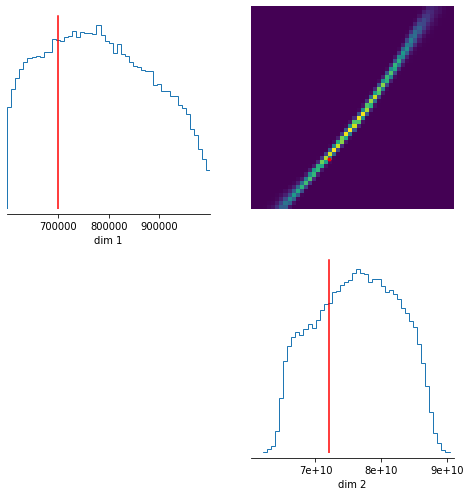

In [59]:
samples = posterior.sample((100000,), x=observation)

_ = analysis.pairplot(samples,
                      points=np.array(true_params),
                      figsize=(8,8),
                      #limits=[[6E5,10E5]],
                      points_colors='r',
                      points_offdiag={'markersize': 6},
                     )

print('UA is ',samples[:,0].mean(),'+-',3*samples[:,0].std())
print('k_0 is ',samples[:,1].mean(),'+-',3*samples[:,1].std())

## Sensitivity Study for repeated runs

There is a stochastic element in this, hence the need to establish how sensitive predictions are on case to case runs. Previous runs showed that around 1000 simulations was best for returning the true parameters. Using this value, let's do repeated runs to see if we get repeatable solutions.

In [60]:
store = []
for num_sim in range(10):

    samples = run_sbi(inlet_conditions, observation,num_simulations=1000)
    
    par_1 = [float(sample[0]) for sample in samples]
    par_2 = [float(sample[1]) for sample in samples]
    store.append([par_1,par_2])
  

/home/keepfloyding/.env/lib64/python3.9/site-packages/scipy/integrate/_ivp/base.py:20: FutureWarning: The input object of type 'Tensor' is an array-like implementing one of the corresponding protocols (`__array__`, `__array_interface__` or `__array_struct__`); but not a sequence (or 0-D). In the future, this object will be coerced as if it was first converted using `np.array(obj)`. To retain the old behaviour, you have to either modify the type 'Tensor', or assign to an empty array created with `np.empty(correct_shape, dtype=object)`.
  return np.asarray(fun(t, y), dtype=dtype)


Running 1000 simulations in 1000 batches.:   0%|          | 0/1000 [00:00<?, ?it/s]

/home/keepfloyding/Projects/inso-po-RD/cstr-model-optimisation/tools.py:75: RuntimeWarning: Solution not converged. [1.18807934 0.04726358 0.09675577]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
/home/keepfloyding/Projects/inso-po-RD/cstr-model-optimisation/tools.py:75: RuntimeWarning: Solution not converged. [2.47767334 0.02272853 0.0613894 ]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
/home/keepfloyding/Projects/inso-po-RD/cstr-model-optimisation/tools.py:75: RuntimeWarning: Solution not converged. [1.31714215 0.0466849  0.01479562]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
/home/keepfloyding/Projects/inso-po-RD/cstr-model-optimisation/tools.py:75: RuntimeWarning: Solution not converged. [1.32726265 0.03123643 0.09207029]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
/home/keepfloyding/Projects/inso-po-RD/cstr-model-optimisation/tools.py:75: RuntimeWarning: Solution not con

 Neural network successfully converged after 92 epochs.

Running 1000 simulations in 1000 batches.:   0%|          | 0/1000 [00:00<?, ?it/s]

...

/home/keepfloyding/Projects/inso-po-RD/cstr-model-optimisation/tools.py:75: RuntimeWarning: Solution not converged. [8.93324026 0.33781917 0.3749127 ]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
/home/keepfloyding/Projects/inso-po-RD/cstr-model-optimisation/tools.py:75: RuntimeWarning: Solution not converged. [1.53484198 0.06151583 0.03581155]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
/home/keepfloyding/Projects/inso-po-RD/cstr-model-optimisation/tools.py:75: RuntimeWarning: Solution not converged. [1.41711917 0.08042083 0.01396991]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
/home/keepfloyding/Projects/inso-po-RD/cstr-model-optimisation/tools.py:75: RuntimeWarning: Solution not converged. [1.74648167 0.09569881 0.10055059]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
/home/keepfloyding/Projects/inso-po-RD/cstr-model-optimisation/tools.py:75: RuntimeWarning: Solution not con

 Neural network successfully converged after 176 epochs.

Running 1000 simulations in 1000 batches.:   0%|          | 0/1000 [00:00<?, ?it/s]

/home/keepfloyding/Projects/inso-po-RD/cstr-model-optimisation/tools.py:75: RuntimeWarning: Solution not converged. [5.50313181 0.19808824 0.0997222 ]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
/home/keepfloyding/Projects/inso-po-RD/cstr-model-optimisation/tools.py:75: RuntimeWarning: Solution not converged. [1.12478502 0.04115696 0.06235728]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
/home/keepfloyding/Projects/inso-po-RD/cstr-model-optimisation/tools.py:75: RuntimeWarning: Solution not converged. [1.35397512 0.0829341  0.02822027]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
/home/keepfloyding/Projects/inso-po-RD/cstr-model-optimisation/tools.py:75: RuntimeWarning: Solution not converged. [7.40433883 0.33889772 0.25247706]
  warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
/home/keepfloyding/Projects/inso-po-RD/cstr-model-optimisation/tools.py:75: RuntimeWarning: Solution not con

 Neural network successfully converged after 231 epochs.

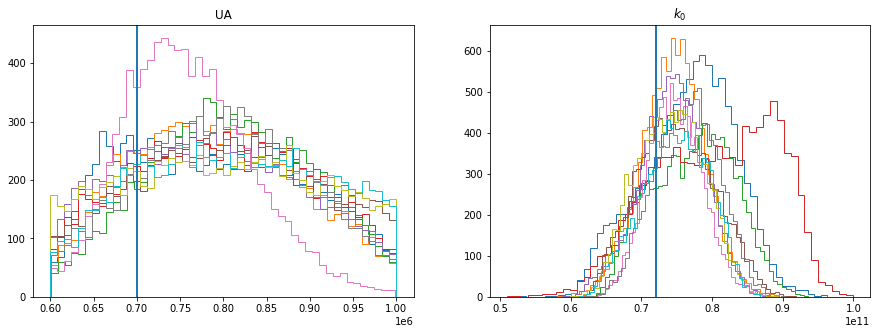

In [65]:
# Plotting the parameters  
plt.subplots(1,2,figsize=(15,5))

UA, k_0 = true_params

plt.subplot(1,2,1)
for item in store:
    plt.title('UA')
    _ = plt.hist(item[0],bins=50,histtype='step')
    plt.axvline(UA)


plt.subplot(1,2,2)
for item in store:
    plt.title('$k_0$')
    _ = plt.hist(item[1],bins=50,histtype='step')
    plt.axvline(k_0)
